In [23]:
# 1. Install DuckDB and Faker for synthetic enterprise data generation
!pip install duckdb faker pandas numpy -q

import duckdb
import pandas as pd
import numpy as np
from faker import Faker
from datetime import datetime, timedelta
import random

fake = Faker()
np.random.seed(42)
random.seed(42)

# Connect to in-memory DuckDB database
con = duckdb.connect(database=':memory:')

print("Generating enterprise e-commerce dataset...")

# --- A. Generate Dimension: dim_customers ---
n_customers = 10000
channels = ['Paid Search', 'Meta Ads', 'Organic Search', 'Influencer', 'Email Referral']
channel_weights = [0.35, 0.25, 0.20, 0.12, 0.08]

customer_data = {
    'customer_id': np.arange(1001, 1001 + n_customers),
    'signup_date': [fake.date_between(start_date='-2y', end_date='-60d') for _ in range(n_customers)],
    'acquisition_channel': np.random.choice(channels, size=n_customers, p=channel_weights),
    'city': np.random.choice(['Bengaluru', 'Mumbai', 'Delhi NCR', 'Hyderabad', 'Pune'], size=n_customers)
}
dim_customers = pd.DataFrame(customer_data)
dim_customers['signup_date'] = pd.to_datetime(dim_customers['signup_date'])

# --- B. Generate Dimension: dim_products ---
products = [
    ('P101', 'Electronics', 1200.0, 1999.0),
    ('P102', 'Electronics', 450.0, 799.0),
    ('P103', 'Fashion', 300.0, 899.0),
    ('P104', 'Fashion', 600.0, 1499.0),
    ('P105', 'Home & Kitchen', 400.0, 999.0),
    ('P106', 'Beauty & Grooming', 150.0, 499.0),
    ('P107', 'Beauty & Grooming', 250.0, 699.0)
]
dim_products = pd.DataFrame(products, columns=['product_id', 'category', 'supplier_cost', 'retail_price'])

# --- C. Generate Fact: fact_orders ---
n_orders = 50000
order_cust_ids = np.random.choice(dim_customers['customer_id'], size=n_orders)
order_prod_ids = np.random.choice(dim_products['product_id'], size=n_orders)

orders_df = pd.DataFrame({
    'order_id': [f"ORD-{i:06d}" for i in range(1, n_orders + 1)],
    'customer_id': order_cust_ids,
    'product_id': order_prod_ids
})

# Merge to bring in signup date and retail price
orders_df = orders_df.merge(dim_customers[['customer_id', 'signup_date', 'acquisition_channel']], on='customer_id')
orders_df = orders_df.merge(dim_products[['product_id', 'retail_price', 'supplier_cost']], on='product_id')

# Generate order dates occurring on or after signup date
orders_df['order_date'] = orders_df['signup_date'].apply(
    lambda d: d + timedelta(days=int(np.random.exponential(scale=45)))
)
# Keep only orders up to today
orders_df = orders_df[orders_df['order_date'] <= pd.to_datetime('today')].reset_index(drop=True)

# Generate quantities and discounting behavior
orders_df['quantity'] = np.random.choice([1, 2, 3], size=len(orders_df), p=[0.75, 0.20, 0.05])
orders_df['gross_amount'] = orders_df['retail_price'] * orders_df['quantity']

# Discounting strategy: Paid channels have heavier promo codes
def apply_discount(row):
    if row['acquisition_channel'] in ['Paid Search', 'Meta Ads']:
        disc_rate = np.random.choice([0.0, 0.15, 0.25, 0.35], p=[0.2, 0.3, 0.3, 0.2])
    else:
        disc_rate = np.random.choice([0.0, 0.05, 0.10], p=[0.6, 0.3, 0.1])
    return round(row['gross_amount'] * disc_rate, 2)

orders_df['discount_amount'] = orders_df.apply(apply_discount, axis=1)
orders_df['net_revenue'] = orders_df['gross_amount'] - orders_df['discount_amount']
orders_df['shipping_cost'] = np.random.choice([60.0, 80.0, 100.0], size=len(orders_df), p=[0.5, 0.3, 0.2])
orders_df['payment_fee'] = (orders_df['net_revenue'] * 0.02).round(2)

fact_orders = orders_df[['order_id', 'customer_id', 'product_id', 'order_date',
                         'quantity', 'gross_amount', 'discount_amount', 'net_revenue',
                         'shipping_cost', 'payment_fee']]

# --- D. Register in DuckDB Tables ---
con.execute("CREATE TABLE dim_customers AS SELECT * FROM dim_customers")
con.execute("CREATE TABLE dim_products AS SELECT * FROM dim_products")
con.execute("CREATE TABLE fact_orders AS SELECT * FROM fact_orders")

print("Tables successfully loaded in DuckDB:")
print(con.execute("SHOW TABLES").df())

Generating enterprise e-commerce dataset...
Tables successfully loaded in DuckDB:
            name
0  dim_customers
1   dim_products
2    fact_orders


In [24]:
# --- STEP 2: Channel-Level Unit Economics & Margin Decomposition ---

query_unit_economics = """
WITH order_costs AS (
    SELECT
        fo.order_id,
        fo.customer_id,
        fo.order_date,
        fo.quantity,
        fo.gross_amount,
        fo.discount_amount,
        fo.net_revenue,
        fo.shipping_cost,
        fo.payment_fee,
        dp.supplier_cost * fo.quantity AS total_cogs,
        dc.acquisition_channel
    FROM fact_orders fo
    INNER JOIN dim_products dp
        ON fo.product_id = dp.product_id
    INNER JOIN dim_customers dc
        ON fo.customer_id = dc.customer_id
)
SELECT
    acquisition_channel,
    COUNT(DISTINCT order_id) AS total_orders,
    COUNT(DISTINCT customer_id) AS active_customers,
    ROUND(SUM(gross_amount), 2) AS total_gmv,
    ROUND(SUM(discount_amount), 2) AS total_discounts,
    ROUND(SUM(net_revenue), 2) AS total_net_revenue,

    -- Discount Rate (%)
    ROUND((SUM(discount_amount) / SUM(gross_amount)) * 100, 2) AS discount_rate_pct,

    -- Average Order Value (AOV)
    ROUND(SUM(net_revenue) / COUNT(DISTINCT order_id), 2) AS aov,

    -- Contribution Margin 1 (Gross Profit)
    ROUND(SUM(net_revenue) - SUM(total_cogs), 2) AS cm1_gross_profit,

    -- Contribution Margin 2 (After Logistics & Gateway Fees)
    ROUND(SUM(net_revenue) - SUM(total_cogs) - SUM(shipping_cost) - SUM(payment_fee), 2) AS cm2_operating_profit,

    -- CM2 Margin (%)
    ROUND(((SUM(net_revenue) - SUM(total_cogs) - SUM(shipping_cost) - SUM(payment_fee)) / SUM(net_revenue)) * 100, 2) AS cm2_margin_pct

FROM order_costs
GROUP BY acquisition_channel
ORDER BY cm2_margin_pct DESC;
"""

df_unit_economics = con.execute(query_unit_economics).df()
print("--- CHANNEL UNIT ECONOMICS & MARGIN BREAKDOWN ---")
display(df_unit_economics)

--- CHANNEL UNIT ECONOMICS & MARGIN BREAKDOWN ---


,acquisition_channel,total_orders,active_customers,total_gmv,total_discounts,total_net_revenue,discount_rate_pct,aov,cm1_gross_profit,cm2_operating_profit,cm2_margin_pct
0,Email Referral,3857,782,5350829.0,133233.10,5217595.90,2.49,1352.76,2804845.90,2415176.25,46.29
1,Organic Search,9693,1919,13239971.0,335496.55,12904474.45,2.53,1331.32,6939224.45,5963320.96,46.21
2,Influencer,5755,1170,7882773.0,199140.55,7683632.45,2.53,1335.12,4103582.45,3522993.40,45.85
3,Meta Ads,12577,2531,17340414.0,3262748.90,14077665.10,18.82,1119.32,6239165.10,5029486.83,35.73
4,Paid Search,17265,3535,23618071.0,4475539.15,19142531.85,18.95,1108.75,8403731.85,6739761.37,35.21


In [25]:
# --- STEP 3: Customer Cohort Retention Matrix ---

query_cohort = """
WITH user_first_order AS (
    -- Step A: Find the first order date for each customer
    SELECT
        customer_id,
        MIN(order_date) AS first_order_date,
        DATE_TRUNC('month', MIN(order_date)) AS cohort_month
    FROM fact_orders
    GROUP BY customer_id
),
user_activities AS (
    -- Step B: Calculate the month index (M0, M1, M2...) for each transaction
    SELECT
        fo.customer_id,
        ufo.cohort_month,
        DATE_TRUNC('month', fo.order_date) AS order_month,
        -- Calculate month difference
        (EXTRACT(YEAR FROM fo.order_date) - EXTRACT(YEAR FROM ufo.cohort_month)) * 12 +
        (EXTRACT(MONTH FROM fo.order_date) - EXTRACT(MONTH FROM ufo.cohort_month)) AS month_index
    FROM fact_orders fo
    INNER JOIN user_first_order ufo
        ON fo.customer_id = ufo.customer_id
),
cohort_sizes AS (
    -- Step C: Count total distinct customers in each cohort (Month 0 size)
    SELECT
        cohort_month,
        COUNT(DISTINCT customer_id) AS total_cohort_users
    FROM user_first_order
    GROUP BY cohort_month
),
retention_counts AS (
    -- Step D: Count active users per month index
    SELECT
        ua.cohort_month,
        ua.month_index,
        COUNT(DISTINCT ua.customer_id) AS active_users
    FROM user_activities ua
    GROUP BY ua.cohort_month, ua.month_index
)
-- Step E: Build the final cohort matrix table
SELECT
    STRFTIME(cs.cohort_month, '%Y-%m') AS cohort,
    cs.total_cohort_users,
    ROUND(100.0 * MAX(CASE WHEN rc.month_index = 0 THEN rc.active_users ELSE 0 END) / cs.total_cohort_users, 1) AS m0_pct,
    ROUND(100.0 * MAX(CASE WHEN rc.month_index = 1 THEN rc.active_users ELSE 0 END) / cs.total_cohort_users, 1) AS m1_pct,
    ROUND(100.0 * MAX(CASE WHEN rc.month_index = 2 THEN rc.active_users ELSE 0 END) / cs.total_cohort_users, 1) AS m2_pct,
    ROUND(100.0 * MAX(CASE WHEN rc.month_index = 3 THEN rc.active_users ELSE 0 END) / cs.total_cohort_users, 1) AS m3_pct,
    ROUND(100.0 * MAX(CASE WHEN rc.month_index = 4 THEN rc.active_users ELSE 0 END) / cs.total_cohort_users, 1) AS m4_pct,
    ROUND(100.0 * MAX(CASE WHEN rc.month_index = 5 THEN rc.active_users ELSE 0 END) / cs.total_cohort_users, 1) AS m5_pct
FROM cohort_sizes cs
LEFT JOIN retention_counts rc
    ON cs.cohort_month = rc.cohort_month
WHERE cs.cohort_month >= '2024-01-01' AND cs.cohort_month <= '2024-08-01'
GROUP BY cs.cohort_month, cs.total_cohort_users
ORDER BY cs.cohort_month;
"""

df_cohort = con.execute(query_cohort).df()
print("--- CUSTOMER COHORT RETENTION MATRIX (%) ---")
display(df_cohort)

--- CUSTOMER COHORT RETENTION MATRIX (%) ---


,cohort,total_cohort_users,m0_pct,m1_pct,m2_pct,m3_pct,m4_pct,m5_pct
0,2024-08,22,100.0,90.9,68.2,50.0,13.6,18.2


In [26]:
# --- STEP 4: Advanced Window Functions & RFM / LTV Decile Segmentation ---

query_rfm_segmentation = """
WITH customer_order_summary AS (
    -- Step A: Aggregate lifecycle stats per customer
    SELECT
        fo.customer_id,
        dc.acquisition_channel,
        dc.city,
        COUNT(DISTINCT fo.order_id) AS lifetime_orders,
        ROUND(SUM(fo.gross_amount), 2) AS total_gross_spend,
        ROUND(SUM(fo.discount_amount), 2) AS total_discount_received,
        ROUND(SUM(fo.net_revenue), 2) AS customer_ltv,
        MAX(fo.order_date) AS last_order_date,
        MIN(fo.order_date) AS first_order_date
    FROM fact_orders fo
    INNER JOIN dim_customers dc
        ON fo.customer_id = dc.customer_id
    GROUP BY fo.customer_id, dc.acquisition_channel, dc.city
),
customer_ranked AS (
    -- Step B: Apply Window Functions (NTILE deciles and Recency calculation)
    SELECT
        customer_id,
        acquisition_channel,
        city,
        lifetime_orders,
        customer_ltv,
        total_discount_received,
        -- Calculate days since last purchase (Recency)
        DATE_DIFF('day', last_order_date, '2026-08-20'::DATE) AS days_since_last_order,

        -- Window Function 1: Divide customers into 10 equal spend deciles (10 = Top 10% Spenders)
        NTILE(10) OVER (ORDER BY customer_ltv ASC) AS spend_decile,

        -- Window Function 2: Rank order within channel
        DENSE_RANK() OVER (PARTITION BY acquisition_channel ORDER BY customer_ltv DESC) AS channel_rank
    FROM customer_order_summary
),
customer_segmented AS (
    -- Step C: Assign business tier labels based on multi-variable logic
    SELECT
        *,
        CASE
            WHEN spend_decile = 10 AND lifetime_orders >= 4 THEN '1. VIP Power Buyer'
            WHEN spend_decile >= 7 AND days_since_last_order <= 90 THEN '2. Core Active'
            WHEN lifetime_orders = 1 AND total_discount_received > 200 THEN '3. One-Time Deal Hunter'
            WHEN days_since_last_order > 180 THEN '4. Churned / Inactive'
            ELSE '5. Occasional Shopper'
        END AS customer_segment
    FROM customer_ranked
)
-- Step D: Segment-Level Unit Economics Rollup
SELECT
    customer_segment,
    COUNT(DISTINCT customer_id) AS total_customers,
    ROUND(AVG(lifetime_orders), 1) AS avg_orders_per_user,
    ROUND(AVG(customer_ltv), 2) AS avg_ltv_inr,
    ROUND(AVG(total_discount_received), 2) AS avg_discount_given,
    ROUND(SUM(customer_ltv), 2) AS total_segment_revenue,
    ROUND(100.0 * SUM(customer_ltv) / SUM(SUM(customer_ltv)) OVER(), 2) AS pct_of_total_revenue
FROM customer_segmented
GROUP BY customer_segment
ORDER BY avg_ltv_inr DESC;
"""

df_segments = con.execute(query_rfm_segmentation).df()
print("--- CUSTOMER SEGMENTATION & REVENUE CONCENTRATION ---")
display(df_segments)

--- CUSTOMER SEGMENTATION & REVENUE CONCENTRATION ---


,customer_segment,total_customers,avg_orders_per_user,avg_ltv_inr,avg_discount_given,total_segment_revenue,pct_of_total_revenue
0,1. VIP Power Buyer,991,8.2,12616.52,1281.04,12502973.00,21.18
1,2. Core Active,579,6.2,7958.50,1058.84,4607968.80,7.81
2,4. Churned / Inactive,5954,4.6,5252.05,799.69,31270715.95,52.98
3,5. Occasional Shopper,2290,4.2,4571.21,745.90,10468060.25,17.73
4,3. One-Time Deal Hunter,123,1.0,1432.37,440.08,176181.75,0.30


--- CHANNEL CAC PAYBACK PERIOD ANALYSIS ---


,acquisition_channel,blended_cac,avg_cm2_per_order,orders_to_breakeven_cac
0,Email Referral,25.0,626.18,0.04
1,Influencer,220.0,612.16,0.36
2,Meta Ads,380.0,399.90,0.95
3,Organic Search,40.0,615.22,0.07
4,Paid Search,450.0,390.37,1.15


/tmp/ipykernel_1148/2101649306.py:73: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_1148/2101649306.py:88: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


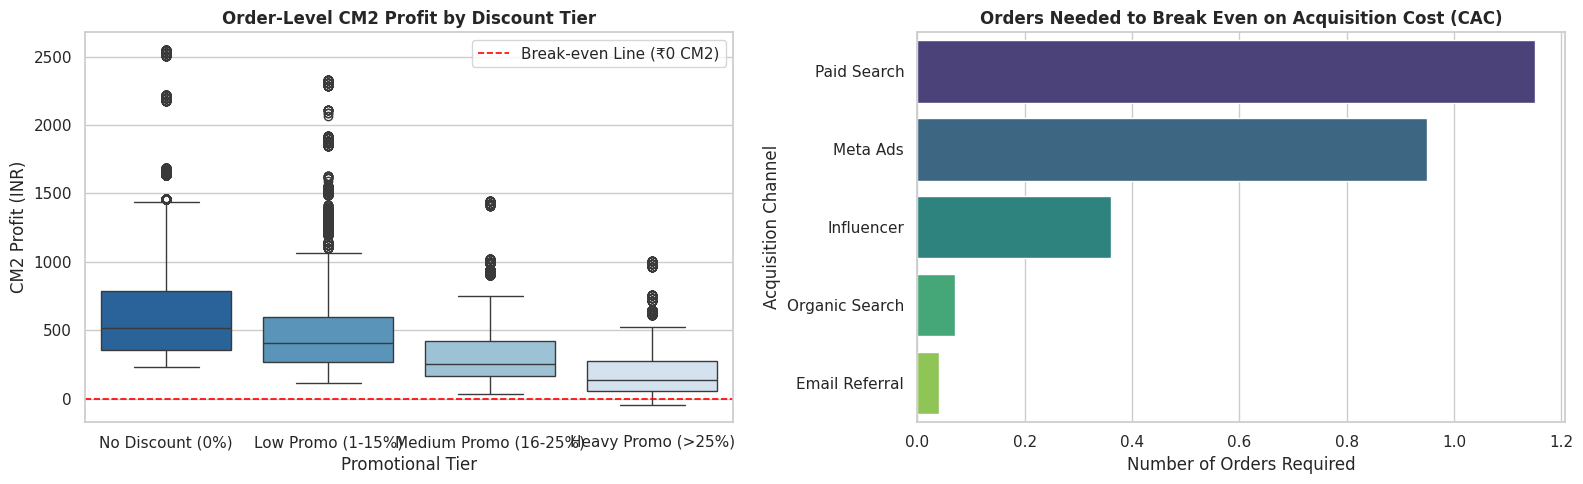

In [27]:
# --- STEP 5: Python Statistical EDA & CAC Payback Sensitivity ---

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Set visualization style
sns.set_theme(style="whitegrid")
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'

# 1. Pull order-level data from DuckDB into a Pandas DataFrame
query_eda = """
SELECT
    fo.order_id,
    fo.customer_id,
    fo.quantity,
    fo.gross_amount,
    fo.discount_amount,
    fo.net_revenue,
    fo.shipping_cost,
    fo.payment_fee,
    dp.supplier_cost * fo.quantity AS total_cogs,
    (fo.net_revenue - (dp.supplier_cost * fo.quantity) - fo.shipping_cost - fo.payment_fee) AS order_cm2_profit,
    ROUND((fo.discount_amount / NULLIF(fo.gross_amount, 0)) * 100, 1) AS discount_pct,
    dc.acquisition_channel
FROM fact_orders fo
INNER JOIN dim_products dp ON fo.product_id = dp.product_id
INNER JOIN dim_customers dc ON fo.customer_id = dc.customer_id;
"""
df_orders = con.execute(query_eda).df()

# 2. Bucket discounts into distinct promo tiers
def discount_tier(pct):
    if pct == 0:
        return 'No Discount (0%)'
    elif pct <= 15:
        return 'Low Promo (1-15%)'
    elif pct <= 25:
        return 'Medium Promo (16-25%)'
    else:
        return 'Heavy Promo (>25%)'

df_orders['promo_tier'] = df_orders['discount_pct'].apply(discount_tier)

# 3. Model Channel CAC Assumptions (Standard Tech Industry Benchmarks)
cac_benchmarks = {
    'Paid Search': 450.0,
    'Meta Ads': 380.0,
    'Influencer': 220.0,
    'Organic Search': 40.0,
    'Email Referral': 25.0
}

# 4. Calculate Margin & Payback per Channel
channel_summary = df_orders.groupby('acquisition_channel').agg(
    total_orders=('order_id', 'count'),
    total_customers=('customer_id', 'nunique'),
    total_cm2_profit=('order_cm2_profit', 'sum')
).reset_index()

channel_summary['blended_cac'] = channel_summary['acquisition_channel'].map(cac_benchmarks)
channel_summary['avg_cm2_per_order'] = (channel_summary['total_cm2_profit'] / channel_summary['total_orders']).round(2)
channel_summary['orders_to_breakeven_cac'] = (channel_summary['blended_cac'] / channel_summary['avg_cm2_per_order']).round(2)

print("--- CHANNEL CAC PAYBACK PERIOD ANALYSIS ---")
display(channel_summary[['acquisition_channel', 'blended_cac', 'avg_cm2_per_order', 'orders_to_breakeven_cac']])

# 5. Visual EDA: Plot Profit Distribution by Promo Tier
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Plot A: Order CM2 Profit Boxplot by Promo Tier
tier_order = ['No Discount (0%)', 'Low Promo (1-15%)', 'Medium Promo (16-25%)', 'Heavy Promo (>25%)']
sns.boxplot(
    data=df_orders,
    x='promo_tier',
    y='order_cm2_profit',
    order=tier_order,
    palette='Blues_r',
    ax=axes[0]
)
axes[0].axhline(0, color='red', linestyle='--', linewidth=1.2, label='Break-even Line (₹0 CM2)')
axes[0].set_title('Order-Level CM2 Profit by Discount Tier', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Promotional Tier')
axes[0].set_ylabel('CM2 Profit (INR)')
axes[0].legend()

# Plot B: Orders Needed to Break Even by Acquisition Channel
sns.barplot(
    data=channel_summary.sort_values('orders_to_breakeven_cac', ascending=False),
    x='orders_to_breakeven_cac',
    y='acquisition_channel',
    palette='viridis',
    ax=axes[1]
)
axes[1].set_title('Orders Needed to Break Even on Acquisition Cost (CAC)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Number of Orders Required')
axes[1].set_ylabel('Acquisition Channel')

plt.tight_layout()
plt.show()

In [28]:
# --- ADVANCED SQL LAYER: Inter-Purchase Velocity & Rolling Margin Windows ---

query_advanced_sql = """
WITH order_gaps AS (
    SELECT
        fo.customer_id,
        fo.order_id,
        fo.order_date,
        fo.net_revenue,
        -- Window Function: Get previous order date for the same customer
        LAG(fo.order_date, 1) OVER (
            PARTITION BY fo.customer_id
            ORDER BY fo.order_date ASC
        ) AS previous_order_date,

        -- Window Function: Calculate cumulative lifetime spend up to this specific order
        SUM(fo.net_revenue) OVER (
            PARTITION BY fo.customer_id
            ORDER BY fo.order_date ASC
            ROWS BETWEEN UNBOUNDED PRECEDING AND CURRENT ROW
        ) AS running_cumulative_spend,

        -- Window Function: Customer's lifetime order sequence number
        ROW_NUMBER() OVER (
            PARTITION BY fo.customer_id
            ORDER BY fo.order_date ASC
        ) AS order_sequence_number
    FROM fact_orders fo
),
inter_purchase_intervals AS (
    SELECT
        customer_id,
        order_id,
        order_date,
        net_revenue,
        running_cumulative_spend,
        order_sequence_number,
        DATE_DIFF('day', previous_order_date, order_date) AS days_since_prior_order
    FROM order_gaps
)
-- Aggregate average days between repeat purchases by order sequence
SELECT
    order_sequence_number,
    COUNT(DISTINCT customer_id) AS total_customers_at_stage,
    ROUND(AVG(days_since_prior_order), 1) AS avg_days_since_previous_order,
    ROUND(AVG(net_revenue), 2) AS avg_order_value_at_stage,
    ROUND(AVG(running_cumulative_spend), 2) AS avg_cumulative_ltv_to_stage
FROM inter_purchase_intervals
WHERE order_sequence_number <= 5
GROUP BY order_sequence_number
ORDER BY order_sequence_number ASC;
"""

df_velocity = con.execute(query_advanced_sql).df()
print("--- CUSTOMER INTER-PURCHASE VELOCITY & CUMULATIVE LTV EXPANSION ---")
display(df_velocity)

--- CUSTOMER INTER-PURCHASE VELOCITY & CUMULATIVE LTV EXPANSION ---


,order_sequence_number,total_customers_at_stage,avg_days_since_previous_order,avg_order_value_at_stage,avg_cumulative_ltv_to_stage
0,1,9937,NaN,1196.49,1196.49
1,2,9578,14.9,1185.71,2380.76
2,3,8670,18.1,1207.06,3581.84
3,4,7154,20.9,1199.05,4777.26
4,5,5412,23.8,1212.75,5998.21


In [29]:
# ==============================================================================
# MILESTONE 4 - STEP 4A: Export Analytical Flat Table for BI Dashboard
# ==============================================================================

export_query = """
SELECT
    fo.order_id,
    fo.order_date,
    STRFTIME(fo.order_date, '%Y-%m') AS order_year_month,
    fo.customer_id,
    dc.signup_date,
    STRFTIME(dc.signup_date, '%Y-%m') AS signup_cohort,
    dc.acquisition_channel,
    dc.city,
    fo.product_id,
    dp.category AS product_category,
    fo.quantity,
    fo.gross_amount,
    fo.discount_amount,
    fo.net_revenue,
    fo.shipping_cost,
    fo.payment_fee,
    dp.supplier_cost * fo.quantity AS total_cogs,
    (fo.net_revenue - (dp.supplier_cost * fo.quantity) - fo.shipping_cost - fo.payment_fee) AS cm2_operating_profit,
    ROUND((fo.discount_amount / NULLIF(fo.gross_amount, 0)) * 100, 1) AS discount_pct
FROM fact_orders fo
INNER JOIN dim_customers dc ON fo.customer_id = dc.customer_id
INNER JOIN dim_products dp ON fo.product_id = dp.product_id;
"""

# 1. Execute and load into a dataframe
df_dashboard_export = con.execute(export_query).df()

# 2. Save locally as CSV
df_dashboard_export.to_csv('ecommerce_unit_economics_master.csv', index=False)

print("Export Complete!")
print(f"File created: 'ecommerce_unit_economics_master.csv' with {len(df_dashboard_export):,} rows.")

Export Complete!
File created: 'ecommerce_unit_economics_master.csv' with 49,147 rows.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')